# Clasificación de Ataque Cardíaco — Machine Learning Supervisado
### Estadística Multivariada Avanzada — Universidad EAFIT

**Problema:** Clasificación binaria de presencia de ataque cardíaco (`HadHeartAttack`)  
**Criterio de éxito:** AUC ROC ≥ 0.85  
**Modelos:** Regresión Logística · Random Forest · Gradient Boosting

## 1. Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import loguniform, randint, uniform

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold,
    RepeatedStratifiedKFold, cross_validate
)
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    balanced_accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, confusion_matrix, classification_report,
    log_loss, brier_score_loss, roc_curve, precision_recall_curve
)
from sklearn.utils.class_weight import compute_sample_weight

import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 12})
%matplotlib inline

import pickle
from google.colab import files

## 2. Parámetros globales

In [ ]:
RANDOM_STATE = 42      # semilla global
N_ITER       = 10      # configuraciones por modelo en RandomizedSearchCV (20 × 5 folds = 100 ajustes)
BOOTSTRAP_N  = 1000    # remuestreos bootstrap
SUCCESS_AUC  = 0.85    # criterio mínimo de éxito

## 3. Carga de datos

In [ ]:
df_completo = pd.read_csv('dataset_features_final.csv')

df = df_completo.copy()

TARGET = 'HadHeartAttack'

# ── Submuestra para pruebas rápidas ──────────────────────────────────────────
# Cambia MODO_PRUEBA a False cuando quieras correr con el dataset completo
MODO_PRUEBA = False
N_MUESTRA   = 500

if MODO_PRUEBA:
    # sample() de pandas no tiene stratify → se muestrea por clase manualmente
    df_pos = df[df[TARGET] == 1].sample(frac=N_MUESTRA/len(df), random_state=RANDOM_STATE)
    df_neg = df[df[TARGET] == 0].sample(frac=N_MUESTRA/len(df), random_state=RANDOM_STATE)
    df = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f'\nDataset prueba:')
    print(f'Dimensiones: {df.shape}')
    print(f'\nDistribución de la variable objetivo:')
    print(df['HadHeartAttack'].value_counts())
    print(f'\nProporción positiva: {df["HadHeartAttack"].mean():.4f}')
else:
    print(f'Modo completo: usando {len(df):,} registros.')

print(f'\nDataset completo:')
print(f'Dimensiones: {df_completo.shape}')
print(f'\nDistribución de la variable objetivo:')
print(df_completo['HadHeartAttack'].value_counts())
print(f'\nProporción positiva: {df_completo["HadHeartAttack"].mean():.4f}')
df_completo.head(3)

Modo completo: usando 413,460 registros.

Dataset completo:
Dimensiones: (413460, 95)

Distribución de la variable objetivo:
HadHeartAttack
0    389886
1     23574
Name: count, dtype: int64

Proporción positiva: 0.0570


,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,...,State_Virgin Islands,State_Virginia,State_Washington,State_West Virginia,State_Wisconsin,State_Wyoming,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic"
0,0,3,0.0,0.0,3,0,8.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,4,0.0,0.0,3,0,6.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,3,2.0,3.0,3,1,5.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## 4. Preparación de datasets

- **`df_model`** → dataset base, usado para Random Forest y Gradient Boosting.
- **`df_lr`** → mismas features base + interacciones, usado solo para Regresión Logística.

In [ ]:
# Dataset base: lo usan los modelos de árboles
X = df.drop(columns=[TARGET, 'HadAngina'])
y = df[TARGET]

# Dataset para logística: se agregan variables transformadas e interacciones
df_lr = X.copy()

print('HadAngina eliminada ✓')

# Log del BMI (si el dataset trae BMI en escala original)
if 'BMI' in df_lr.columns and 'BMI_log' not in df_lr.columns:
    df_lr['BMI_log'] = np.log1p(df_lr['BMI'])  # log1p para evitar log(0)
    print('BMI_log creado ✓')
elif 'BMI_log' in df_lr.columns:
    print('BMI_log ya existe en el dataset ✓')

# Interacciones (sin ninguna basada en angina)
if 'BMI_log' in df_lr.columns and 'AgeCategory' in df_lr.columns:
    df_lr['BMI_x_Age'] = df_lr['BMI_log'] * (df_lr['AgeCategory'] + 1)
    print('BMI_x_Age creado ✓')

if 'SmokerStatus' in df_lr.columns and 'HadDiabetes' in df_lr.columns:
    df_lr['Smoker_x_Diabetes'] = df_lr['SmokerStatus'] * df_lr['HadDiabetes']
    print('Smoker_x_Diabetes creado ✓')

if 'BMI_log' in df_lr.columns and 'HadDiabetes' in df_lr.columns:
    df_lr['BMI_x_Diabetes'] = df_lr['BMI_log'] * df_lr['HadDiabetes']
    print('BMI_x_Diabetes creado ✓')

if 'AgeCategory' in df_lr.columns and 'HadDiabetes' in df_lr.columns:
    df_lr['Age_x_Diabetes'] = (df_lr['AgeCategory'] + 1) * df_lr['HadDiabetes']
    print('Age_x_Diabetes creado ✓')

if 'SmokerStatus' in df_lr.columns and 'AgeCategory' in df_lr.columns:
    df_lr['Smoker_x_Age'] = df_lr['SmokerStatus'] * (df_lr['AgeCategory'] + 1)
    print('Smoker_x_Age creado ✓')

feature_names    = X.columns.tolist()
feature_names_lr = df_lr.columns.tolist()

print(f'\nFeatures árboles: {len(feature_names)}')
print(f'Features logística: {len(feature_names_lr)}')

HadAngina eliminada ✓
BMI_log creado ✓
BMI_x_Age creado ✓
Smoker_x_Diabetes creado ✓
BMI_x_Diabetes creado ✓
Age_x_Diabetes creado ✓
Smoker_x_Age creado ✓

Features árboles: 93
Features logística: 99


## 5. Partición train / validation / test
- **60 %** train · **20 %** validation · **20 %** test  
- Estratificada por clase — mismos índices para árboles y logística

In [ ]:
# Partición por índices para garantizar exactamente la misma división en ambos datasets
idx_all = np.arange(len(y))

idx_dev, idx_test = train_test_split(
    idx_all, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
idx_train, idx_val = train_test_split(
    idx_dev, test_size=0.25, random_state=RANDOM_STATE, stratify=y.iloc[idx_dev]
)

# Conjuntos para árboles (sin escalar)
X_train = X.iloc[idx_train].reset_index(drop=True)
X_val   = X.iloc[idx_val].reset_index(drop=True)
X_test  = X.iloc[idx_test].reset_index(drop=True)

# Conjuntos para logística (sin escalar aún — se escalan en la sección siguiente)
X_train_lr = df_lr.iloc[idx_train].reset_index(drop=True)
X_val_lr   = df_lr.iloc[idx_val].reset_index(drop=True)
X_test_lr  = df_lr.iloc[idx_test].reset_index(drop=True)

# Variable objetivo (la misma para todos)
y_train = y.iloc[idx_train].reset_index(drop=True)
y_val   = y.iloc[idx_val].reset_index(drop=True)
y_test  = y.iloc[idx_test].reset_index(drop=True)

for nombre, yp in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    print(f'{nombre:12s}: {len(yp):7,} obs  |  prop. positivos: {yp.mean():.4f}')

Train       : 248,076 obs  |  prop. positivos: 0.0570
Validation  :  82,692 obs  |  prop. positivos: 0.0570
Test        :  82,692 obs  |  prop. positivos: 0.0570


## 6. Escalado para regresión logística
El escalado se maneja con `Pipeline(StandardScaler + LogisticRegression)` directamente
en cada punto donde se entrena LR (modelos base, tuning, CV robusta, reentrenamiento).
Así el scaler se ajusta **solo sobre el sub-train de cada fold**, sin leakage.

In [ ]:
# El escalado de LR se aplica dentro del Pipeline en cada paso del notebook.
# No se escala manualmente aquí para evitar leakage intra-fold en la CV interna.
print('Escalado delegado al Pipeline de LR. Sin acción manual necesaria.')

Escalado delegado al Pipeline de LR. Sin acción manual necesaria.


## 7. Funciones auxiliares

In [ ]:
def youden_threshold(y_true, y_prob):
    """Umbral óptimo maximizando Youden J = sensibilidad + especificidad - 1."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j = tpr + (1 - fpr) - 1
    return float(thresholds[np.argmax(j)])


def f2_threshold(y_true, y_prob):
    """Umbral óptimo maximizando F2-score sobre una grilla de candidatos."""
    candidatos = np.linspace(0.01, 0.99, 200)
    scores = [fbeta_score(y_true, (y_prob >= t).astype(int), beta=2, zero_division=0)
              for t in candidatos]
    return float(candidatos[np.argmax(scores)])


def compute_metrics(y_true, y_prob, threshold=0.5):
    """Devuelve diccionario con métricas de clasificación."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        'roc_auc'     : roc_auc_score(y_true, y_prob),
        'pr_auc'      : average_precision_score(y_true, y_prob),
        'accuracy'    : accuracy_score(y_true, y_pred),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
        'precision'   : precision_score(y_true, y_pred, zero_division=0),
        'recall'      : recall_score(y_true, y_pred, zero_division=0),
        'specificity' : spec,
        'f1'          : f1_score(y_true, y_pred, zero_division=0),
        'f2'          : fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'log_loss'    : log_loss(y_true, y_prob),
        'brier'       : brier_score_loss(y_true, y_prob),
    }


def plot_cm(y_true, y_pred, ax, title='Matriz de Confusión'):
    """Heatmap de matriz de confusión — función reutilizada en todo el notebook."""
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Sin ataque', 'Ataque'],
                yticklabels=['Sin ataque', 'Ataque'])
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(title)


## 8. Modelos base
Evaluación con hiperparámetros por defecto como punto de referencia. Umbral = 0.5.

In [ ]:
# Pesos de muestra para Gradient Boosting (no tiene class_weight nativo)
sw_train = compute_sample_weight('balanced', y_train)

# --- Modelo base 1: Regresión Logística ---
# Pipeline: el scaler se ajusta solo sobre X_train_lr, sin ver X_val_lr
base_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])
base_lr.fit(X_train_lr, y_train)
p_val_base_lr = base_lr.predict_proba(X_val_lr)[:, 1]

# --- Modelo base 2: Random Forest ---
base_rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
base_rf.fit(X_train, y_train)
p_val_base_rf = base_rf.predict_proba(X_val)[:, 1]

# --- Modelo base 3: Gradient Boosting ---
base_gb = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
base_gb.fit(X_train, y_train, sample_weight=sw_train)
p_val_base_gb = base_gb.predict_proba(X_val)[:, 1]

print('ROC AUC y Recall en validation — modelos base:')
for nombre, pv in [
    ('LogisticRegression', p_val_base_lr),
    ('RandomForest',       p_val_base_rf),
    ('GradientBoosting',   p_val_base_gb),
]:
    pred = (pv >= 0.5).astype(int)

    print(f'{nombre:25s}: AUC = {roc_auc_score(y_val, pv):.4f} | Recall = {recall_score(y_val, pred):.7f}')


ROC AUC y Recall en validation — modelos base:
LogisticRegression       : AUC = 0.8429 | Recall = 0.7792153
RandomForest             : AUC = 0.8263 | Recall = 0.0057264
GradientBoosting         : AUC = 0.8434 | Recall = 0.7940615


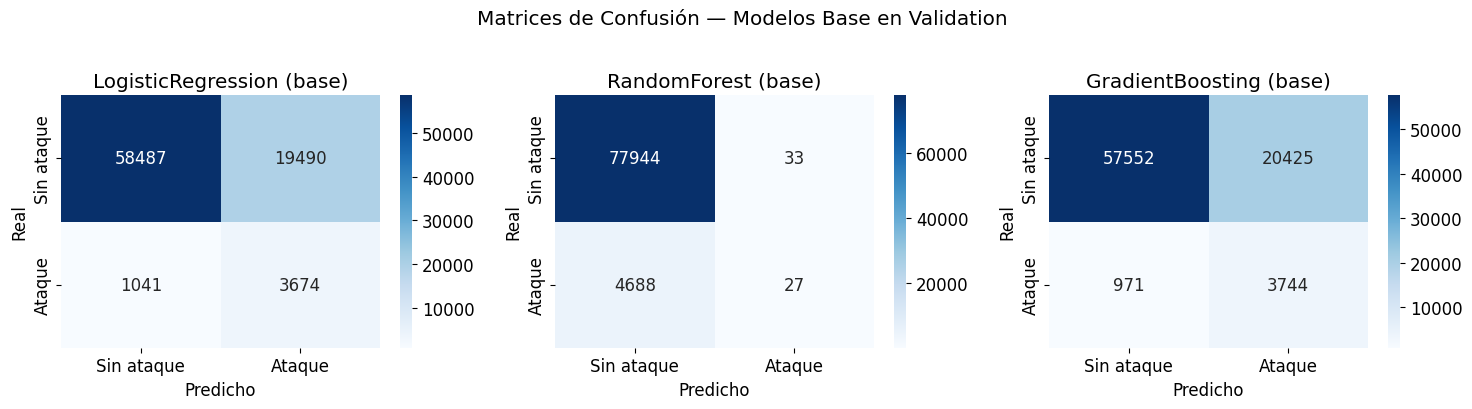

In [ ]:
# Matrices de confusión de los modelos base (umbral 0.5)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, nombre, pv in zip(axes,
    ['LogisticRegression', 'RandomForest', 'GradientBoosting'],
    [p_val_base_lr, p_val_base_rf, p_val_base_gb]
):
    plot_cm(y_val, (pv >= 0.5).astype(int), ax, title=f'{nombre} (base)')

plt.suptitle('Matrices de Confusión — Modelos Base en Validation', y=1.02)
plt.tight_layout()
plt.show()

## 9. Tuneo de hiperparámetros
- `RandomizedSearchCV` con **10 iteraciones × 3 folds = 30 ajustes** por modelo  
- Scoring: `roc_auc` · CV estratificado

In [ ]:
# CV estratificado compartido por los tres modelos
cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# ── Regresión Logística ───────────────────────────────────────────────────────
# Pipeline dentro del RandomizedSearchCV: el scaler se ajusta solo sobre el
# sub-train de cada fold interno → sin leakage intra-fold
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE))
])

# Prefijo clf__ porque los parámetros pertenecen al paso 'clf' del Pipeline
lr_param_space = [
    {'clf__C': loguniform(1e-3, 1e2), 'clf__penalty': ['l1'], 'clf__solver': ['saga', 'liblinear']},
    {'clf__C': loguniform(1e-3, 1e2), 'clf__penalty': ['l2'], 'clf__solver': ['lbfgs', 'saga']},
]

lr_search = RandomizedSearchCV(
    lr_pipe, param_distributions=lr_param_space,
    n_iter=N_ITER, scoring='roc_auc', cv=cv_strat,
    n_jobs=-1, random_state=RANDOM_STATE, refit=True, verbose=3
)
# Se pasa X_train_lr sin escalar — el Pipeline escala dentro de cada fold
lr_search.fit(X_train_lr, y_train)

# Extraer params sin el prefijo clf__ (se usan en el reentrenamiento)
mejores_params_lr = {k.replace('clf__', ''): v for k, v in lr_search.best_params_.items()}

print(f'LR  — mejor ROC AUC CV: {lr_search.best_score_:.4f}')
print(f'LR  — mejores params: {mejores_params_lr}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
LR  — mejor ROC AUC CV: 0.8451
LR  — mejores params: {'C': np.float64(0.0013041036943413024), 'penalty': 'l2', 'solver': 'lbfgs'}


In [ ]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf_param_space = {
    'n_estimators'     : randint(100, 500),
    'max_depth'        : [None, 5, 10, 15, 20],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5],
    'class_weight'     : ['balanced', 'balanced_subsample'],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_space,
    n_iter=N_ITER, scoring='roc_auc', cv=cv_strat,
    n_jobs=-1, random_state=RANDOM_STATE, refit=True, verbose=0
)
rf_search.fit(X_train, y_train)

print(f'RF  — mejor ROC AUC CV: {rf_search.best_score_:.4f}')
print(f'RF  — mejores params: {rf_search.best_params_}')

RF  — mejor ROC AUC CV: 0.8447
RF  — mejores params: {'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 3, 'n_estimators': 439}


In [ ]:
# ── Gradient Boosting ─────────────────────────────────────────────────────────
# GB no tiene class_weight → se pasa sample_weight en fit_params
gb_param_space = {
    'n_estimators'     : randint(100, 400),
    'learning_rate'    : loguniform(1e-3, 0.3),
    'max_depth'        : randint(2, 7),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'subsample'        : uniform(0.5, 0.5),
    'max_features'     : ['sqrt', 'log2', 0.5, None],
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=gb_param_space,
    n_iter=N_ITER, scoring='roc_auc', cv=cv_strat,
    n_jobs=-1, random_state=RANDOM_STATE, refit=True, verbose=0,
)

gb_search.fit(X_train, y_train, sample_weight=sw_train)

print(f'GB  — mejor ROC AUC CV: {gb_search.best_score_:.4f}')
print(f'GB  — mejores params: {gb_search.best_params_}')

GB  — mejor ROC AUC CV: 0.8464
GB  — mejores params: {'learning_rate': np.float64(0.06144386194113441), 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 121, 'subsample': np.float64(0.5035331526098588)}


## 10. Comparación en validation
Se calculan tres umbrales por modelo: **0.5** (base), **Youden J** (maximiza sensibilidad + especificidad)
y **F2** (maximiza F2-score, priorizando recall). Se muestran dos tablas de métricas y una grilla
3×3 de matrices de confusión. Luego el usuario elige el umbral final para cada modelo.

In [ ]:
# LR: best_estimator_ ES el Pipeline (scaler + clf) → recibe datos sin escalar
# RF y GB: reciben datos sin escalar directamente
model_map = {
    'LogisticRegression': (lr_search.best_estimator_, X_val_lr, X_test_lr),
    'RandomForest'      : (rf_search.best_estimator_, X_val,    X_test),
    'GradientBoosting'  : (gb_search.best_estimator_, X_val,    X_test),
}

best_cv = {
    'LogisticRegression': lr_search.best_score_,
    'RandomForest'      : rf_search.best_score_,
    'GradientBoosting'  : gb_search.best_score_,
}

probs_val       = {}
umbrales_youden = {}   # umbral Youden J por modelo
umbrales_f2     = {}   # umbral F2 óptimo por modelo

for nombre, (modelo, Xv, _) in model_map.items():
    pv = modelo.predict_proba(Xv)[:, 1]
    probs_val[nombre]       = pv
    umbrales_youden[nombre] = youden_threshold(y_val, pv)
    umbrales_f2[nombre]     = f2_threshold(y_val, pv)

# --- Tabla con umbral Youden ---
rows_y = []
for nombre in model_map:
    pv = probs_val[nombre]
    thr = umbrales_youden[nombre]
    m = compute_metrics(y_val, pv, threshold=thr)
    rows_y.append({
        'Modelo'             : nombre,
        'ROC AUC_CV (train)' : round(best_cv[nombre], 4),
        'Umbral_Y'      : round(thr, 4),
        'ROC_AUC_val'        : round(m['roc_auc'], 4),
        'PR_AUC_val'         : round(m['pr_auc'], 4),
        'Recall'             : round(m['recall'], 4),
        'Specificity'        : round(m['specificity'], 4),
        'F1'                 : round(m['f1'], 4),
        'F2'                 : round(m['f2'], 4),
        'Balanced_Acc'       : round(m['balanced_acc'], 4),
        'Brier'              : round(m['brier'], 4),
    })

tabla_youden = (
    pd.DataFrame(rows_y)
    .sort_values('ROC_AUC_val', ascending=False)
    .reset_index(drop=True)
)
print('=== Métricas en VALIDATION — Umbral Youden ===')
display(tabla_youden)

# --- Tabla con umbral F2 ---
rows_f2 = []
for nombre in model_map:
    pv = probs_val[nombre]
    thr = umbrales_f2[nombre]
    m = compute_metrics(y_val, pv, threshold=thr)
    rows_f2.append({
        'Modelo'             : nombre,
        'ROC AUC_CV (train)' : round(best_cv[nombre], 4),
        'Umbral_F2'          : round(thr, 4),
        'ROC_AUC_val'        : round(m['roc_auc'], 4),
        'PR_AUC_val'         : round(m['pr_auc'], 4),
        'Recall'             : round(m['recall'], 4),
        'Specificity'        : round(m['specificity'], 4),
        'F1'                 : round(m['f1'], 4),
        'F2'                 : round(m['f2'], 4),
        'Balanced_Acc'       : round(m['balanced_acc'], 4),
        'Brier'              : round(m['brier'], 4),
    })

tabla_f2 = (
    pd.DataFrame(rows_f2)
    .sort_values('ROC_AUC_val', ascending=False)
    .reset_index(drop=True)
)
print('\n=== Métricas en VALIDATION — Umbral F2 ===')
display(tabla_f2)

# tabla_val apunta a la de Youden (usada en selección del mejor modelo)
tabla_val = tabla_youden.copy()
tabla_val = tabla_val.rename(columns={'Umbral_Y': 'Umbral'})


=== Métricas en VALIDATION — Umbral Youden ===


,Modelo,ROC AUC_CV (train),Umbral_Y,ROC_AUC_val,PR_AUC_val,Recall,Specificity,F1,F2,Balanced_Acc,Brier
0,GradientBoosting,0.8464,0.4806,0.8431,0.2551,0.8117,0.7234,0.2542,0.4324,0.7675,0.1659
1,LogisticRegression,0.8451,0.4363,0.8428,0.2549,0.8308,0.7010,0.2452,0.4249,0.7659,0.1653
2,RandomForest,0.8447,0.3135,0.8415,0.2470,0.8019,0.7339,0.2586,0.4357,0.7679,0.0904



=== Métricas en VALIDATION — Umbral F2 ===


,Modelo,ROC AUC_CV (train),Umbral_F2,ROC_AUC_val,PR_AUC_val,Recall,Specificity,F1,F2,Balanced_Acc,Brier
0,GradientBoosting,0.8464,0.6010,0.8431,0.2551,0.7031,0.8096,0.2898,0.4477,0.7563,0.1659
1,LogisticRegression,0.8451,0.5763,0.8428,0.2549,0.6999,0.8086,0.2877,0.4450,0.7543,0.1653
2,RandomForest,0.8447,0.3596,0.8415,0.2470,0.7370,0.7844,0.2780,0.4439,0.7607,0.0904


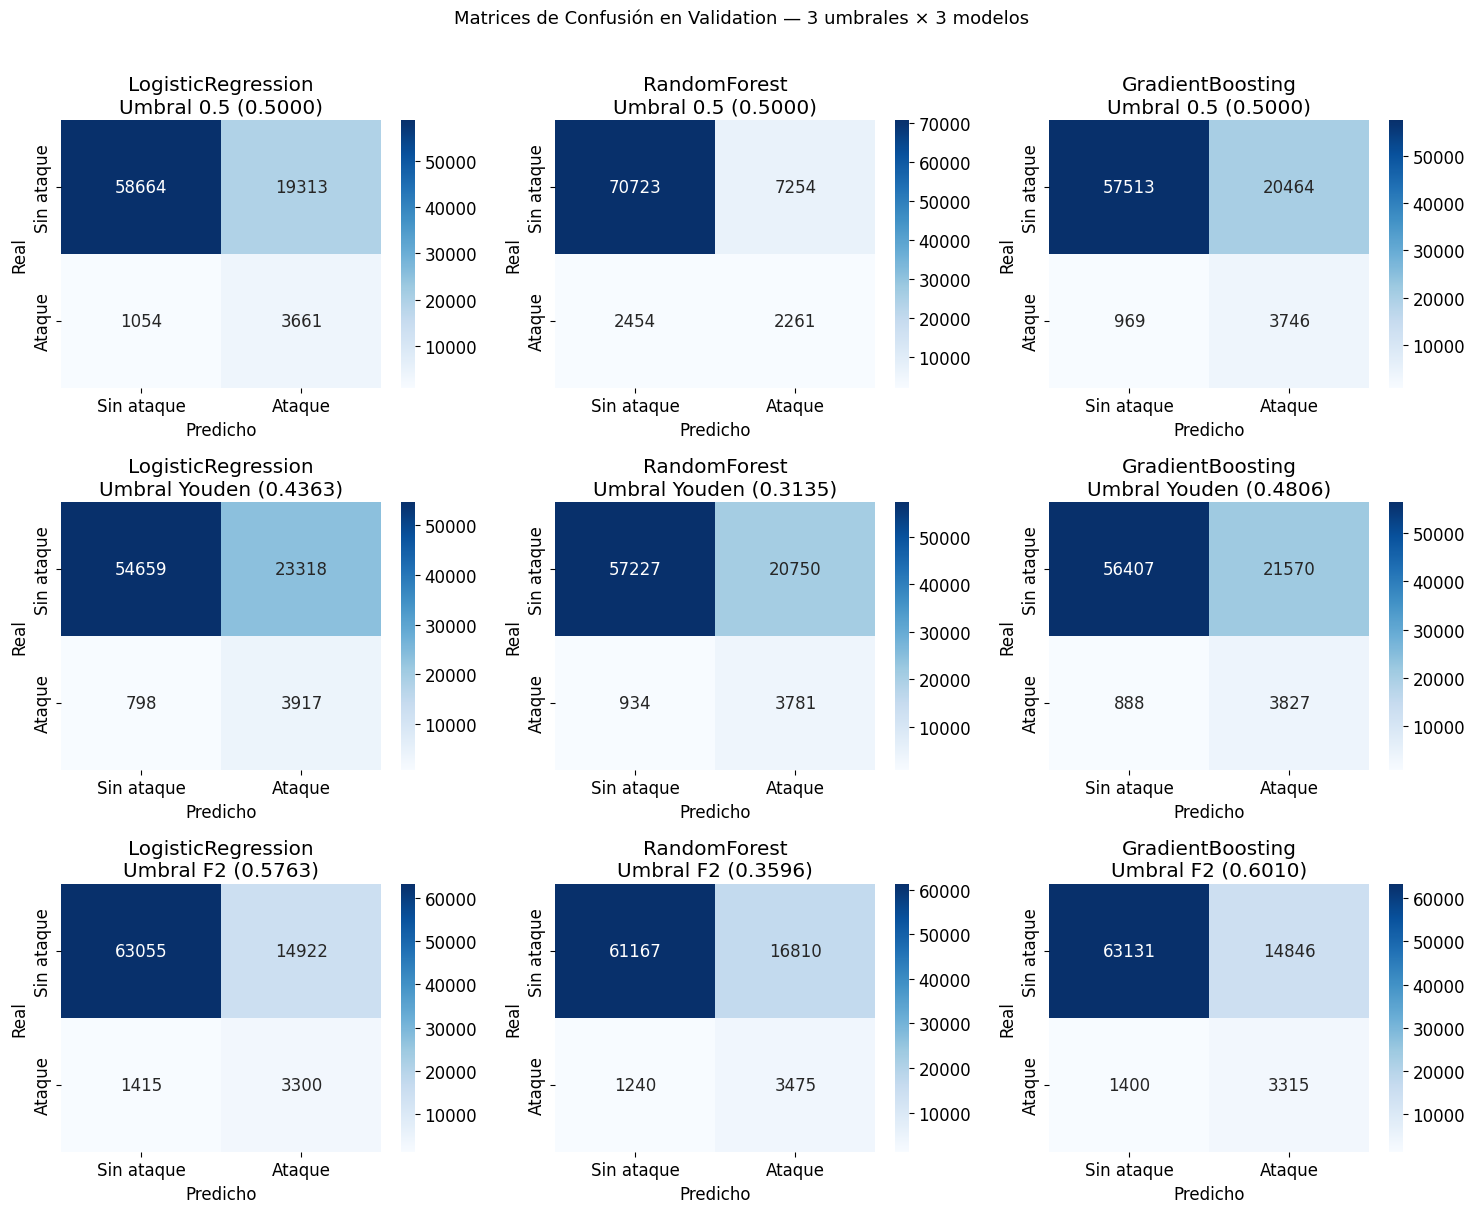

In [ ]:
# Grilla 3x3: filas = umbral (0.5, Youden, F2) | columnas = modelo
nombres = list(model_map.keys())
umbrales_lista = [
    ('0.5',    {n: 0.5                   for n in nombres}),
    ('Youden', umbrales_youden),
    ('F2',     umbrales_f2),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for row_idx, (thr_label, thr_dict) in enumerate(umbrales_lista):
    for col_idx, nombre in enumerate(nombres):
        ax  = axes[row_idx, col_idx]
        pv  = probs_val[nombre]
        thr = thr_dict[nombre]
        plot_cm(y_val, (pv >= thr).astype(int), ax,
                title=f'{nombre}\nUmbral {thr_label} ({thr:.4f})')

plt.suptitle('Matrices de Confusión en Validation — 3 umbrales × 3 modelos', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# ── Elección de umbral por modelo ────────────────────────────────────────────
# Revisa las tablas y matrices de arriba y elige el umbral para cada modelo.
# Puedes escribir 'youden', 'f2', '0.5' o un valor numérico (ej: 0.35).

print('Umbrales disponibles por modelo:')
for nombre in model_map:
    print(f'  {nombre:25s}  Youden={umbrales_youden[nombre]:.4f}  '
          f'F2={umbrales_f2[nombre]:.4f}  Base=0.5000')

print()
umbrales = {}   # diccionario final de umbrales — usado en todo lo que sigue

for nombre in model_map:
    while True:
        entrada = input(f"Umbral para {nombre} [youden / f2 / 0.5 / valor numérico]: ").strip().lower()
        if entrada == 'youden':
            umbrales[nombre] = umbrales_youden[nombre]; break
        elif entrada == 'f2':
            umbrales[nombre] = umbrales_f2[nombre]; break
        elif entrada in ('0.5', 'base'):
            umbrales[nombre] = 0.5; break
        else:
            try:
                val = float(entrada)
                if 0 < val < 1:
                    umbrales[nombre] = val; break
                else:
                    print('  El umbral debe estar entre 0 y 1.')
            except ValueError:
                print('  Entrada no válida. Escribe youden, f2, 0.5 o un número entre 0 y 1.')

print('\nUmbrales elegidos:')
for nombre, thr in umbrales.items():
    print(f'  {nombre:25s}: {thr:.4f}')


Umbrales disponibles por modelo:
  LogisticRegression         Youden=0.4363  F2=0.5763  Base=0.5000
  RandomForest               Youden=0.3135  F2=0.3596  Base=0.5000
  GradientBoosting           Youden=0.4806  F2=0.6010  Base=0.5000

Umbral para LogisticRegression [youden / f2 / 0.5 / valor numérico]: youden
Umbral para RandomForest [youden / f2 / 0.5 / valor numérico]: youden
Umbral para GradientBoosting [youden / f2 / 0.5 / valor numérico]: youden

Umbrales elegidos:
  LogisticRegression       : 0.4363
  RandomForest             : 0.3135
  GradientBoosting         : 0.4806


## 11. Selección del mejor modelo
Criterio: **ROC AUC en validation** (el test no se toca aún).

In [ ]:
mejor_nombre  = tabla_val.iloc[0]['Modelo']
mejor_umbral  = umbrales[mejor_nombre]   # umbral elegido por el usuario
mejor_auc_val = tabla_val.iloc[0]['ROC_AUC_val']

# Para LR los params ya vienen sin prefijo clf__ (extraídos en el tuning)
# Para RF y GB se toman directamente del search
if mejor_nombre == 'LogisticRegression':
    mejores_params = mejores_params_lr
elif mejor_nombre == 'RandomForest':
    mejores_params = rf_search.best_params_
else:
    mejores_params = gb_search.best_params_

print('=' * 55)
print(f'MEJOR MODELO    : {mejor_nombre}')
print(f'Hiperparámetros : {mejores_params}')
print(f'Umbral elegido  : {mejor_umbral:.4f}')
print(f'  (Youden={umbrales_youden[mejor_nombre]:.4f}  '
      f'F2={umbrales_f2[mejor_nombre]:.4f}  Base=0.5)')
print(f'ROC AUC (val)   : {mejor_auc_val:.4f}')
print(f'Cumple ROC AUC >= {SUCCESS_AUC}? {"SÍ ✓" if mejor_auc_val >= SUCCESS_AUC else "NO ✗"}')
print('=' * 55)


MEJOR MODELO    : GradientBoosting
Hiperparámetros : {'learning_rate': np.float64(0.06144386194113441), 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 121, 'subsample': np.float64(0.5035331526098588)}
Umbral elegido  : 0.4806
  (Youden=0.4806  F2=0.6010  Base=0.5)
ROC AUC (val)   : 0.8431
Cumple ROC AUC >= 0.85? NO ✗


## 12. Reentrenamiento final
El mejor modelo se reentrena sobre **train + validation** antes de evaluar en test.

In [ ]:
X_trainval    = pd.concat([X_train, X_val], ignore_index=True)
X_trainval_lr = pd.concat([X_train_lr, X_val_lr], ignore_index=True)
y_trainval    = pd.concat([y_train, y_val], ignore_index=True)

print(f'Tamaño train+val: {len(y_trainval):,} observaciones')

# Función auxiliar para reentrenar un modelo con sus mejores parámetros
def reentrenar(nombre, params):
    if nombre == 'LogisticRegression':
        m = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                class_weight='balanced', max_iter=2000,
                random_state=RANDOM_STATE, **params
            ))
        ])
        m.fit(X_trainval_lr, y_trainval)
        X_t = X_test_lr
    elif nombre == 'RandomForest':
        m = RandomForestClassifier(
            random_state=RANDOM_STATE, n_jobs=-1, **params
        )
        m.fit(X_trainval, y_trainval)
        X_t = X_test
    else:  # GradientBoosting
        sw_tv = compute_sample_weight('balanced', y_trainval)
        m = GradientBoostingClassifier(
            random_state=RANDOM_STATE, **params
        )
        m.fit(X_trainval, y_trainval, sample_weight=sw_tv)
        X_t = X_test
    return m, X_t

# Mejores parámetros por modelo
params_map = {
    'LogisticRegression': mejores_params_lr,
    'RandomForest'      : rf_search.best_params_,
    'GradientBoosting'  : gb_search.best_params_,
}

# Reentrenar los 3 modelos
modelos_finales = {}
X_test_map      = {}
for nombre in model_map:
    modelos_finales[nombre], X_test_map[nombre] = reentrenar(nombre, params_map[nombre])
    print(f'{nombre} reentrenado con train+val. ✓')

# Mantener referencias al mejor modelo para compatibilidad con secciones siguientes
modelo_final  = modelos_finales[mejor_nombre]
X_test_final  = X_test_map[mejor_nombre]


Tamaño train+val: 330,768 observaciones
LogisticRegression reentrenado con train+val. ✓
RandomForest reentrenado con train+val. ✓
GradientBoosting reentrenado con train+val. ✓


## 13. Evaluación final en test
Umbral usado: el elegido por el usuario en validation para cada modelo.

In [ ]:
# Evaluar los 3 modelos en test con los umbrales elegidos por el usuario
test_metrics_todos = {}
for nombre in modelos_finales:
    pt = modelos_finales[nombre].predict_proba(X_test_map[nombre])[:, 1]
    test_metrics_todos[nombre] = compute_metrics(y_test, pt, threshold=umbrales[nombre])

# Tabla comparativa de los 3 modelos en test
rows_test = []
for nombre in modelos_finales:
    m = test_metrics_todos[nombre]
    rows_test.append({
        'Modelo'      : nombre,
        'Umbral'      : round(umbrales[nombre], 4),
        'ROC_AUC'     : round(m['roc_auc'], 4),
        'PR_AUC'      : round(m['pr_auc'], 4),
        'Recall'      : round(m['recall'], 4),
        'Specificity' : round(m['specificity'], 4),
        'Precision'   : round(m['precision'], 4),
        'F1'          : round(m['f1'], 4),
        'F2'          : round(m['f2'], 4),
        'Balanced_Acc': round(m['balanced_acc'], 4),
        'Brier'       : round(m['brier'], 4),
    })

tabla_test = (
    pd.DataFrame(rows_test)
    .sort_values('ROC_AUC', ascending=False)
    .reset_index(drop=True)
)
print('=== Comparación de los 3 modelos en TEST ===')
display(tabla_test)

# Variables del mejor modelo (necesarias para secciones siguientes)
p_test_final = modelos_finales[mejor_nombre].predict_proba(X_test_final)[:, 1]
y_pred_test  = (p_test_final >= mejor_umbral).astype(int)
test_m       = test_metrics_todos[mejor_nombre]

print(f'\n=== {mejor_nombre} — EVALUACIÓN DETALLADA EN TEST ===')
for k, v in test_m.items():
    print(f'  {k:15s}: {v:.5f}')

print(f'\n>>> ¿Cumple ROC AUC >= {SUCCESS_AUC}? {"SÍ ✓" if test_m["roc_auc"] >= SUCCESS_AUC else "NO ✗"}')


=== Comparación de los 3 modelos en TEST ===


,Modelo,Umbral,ROC_AUC,PR_AUC,Recall,Specificity,Precision,F1,F2,Balanced_Acc,Brier
0,GradientBoosting,0.4806,0.8434,0.2630,0.8089,0.7229,0.1501,0.2531,0.4307,0.7659,0.1663
1,RandomForest,0.3135,0.8430,0.2565,0.7975,0.7327,0.1528,0.2565,0.4325,0.7651,0.0909
2,LogisticRegression,0.4363,0.8411,0.2618,0.8274,0.6998,0.1428,0.2436,0.4224,0.7636,0.1654



=== GradientBoosting — EVALUACIÓN DETALLADA EN TEST ===
  roc_auc        : 0.84339
  pr_auc         : 0.26304
  accuracy       : 0.72785
  balanced_acc   : 0.76593
  precision      : 0.15005
  recall         : 0.80891
  specificity    : 0.72294
  f1             : 0.25314
  f2             : 0.43069
  log_loss       : 0.49363
  brier          : 0.16626

>>> ¿Cumple ROC AUC >= 0.85? NO ✗


In [ ]:
print(classification_report(y_test, y_pred_test,
      target_names=['Sin ataque (0)', 'Ataque (1)']))

                precision    recall  f1-score   support

Sin ataque (0)       0.98      0.72      0.83     77977
    Ataque (1)       0.15      0.81      0.25      4715

      accuracy                           0.73     82692
     macro avg       0.57      0.77      0.54     82692
  weighted avg       0.94      0.73      0.80     82692



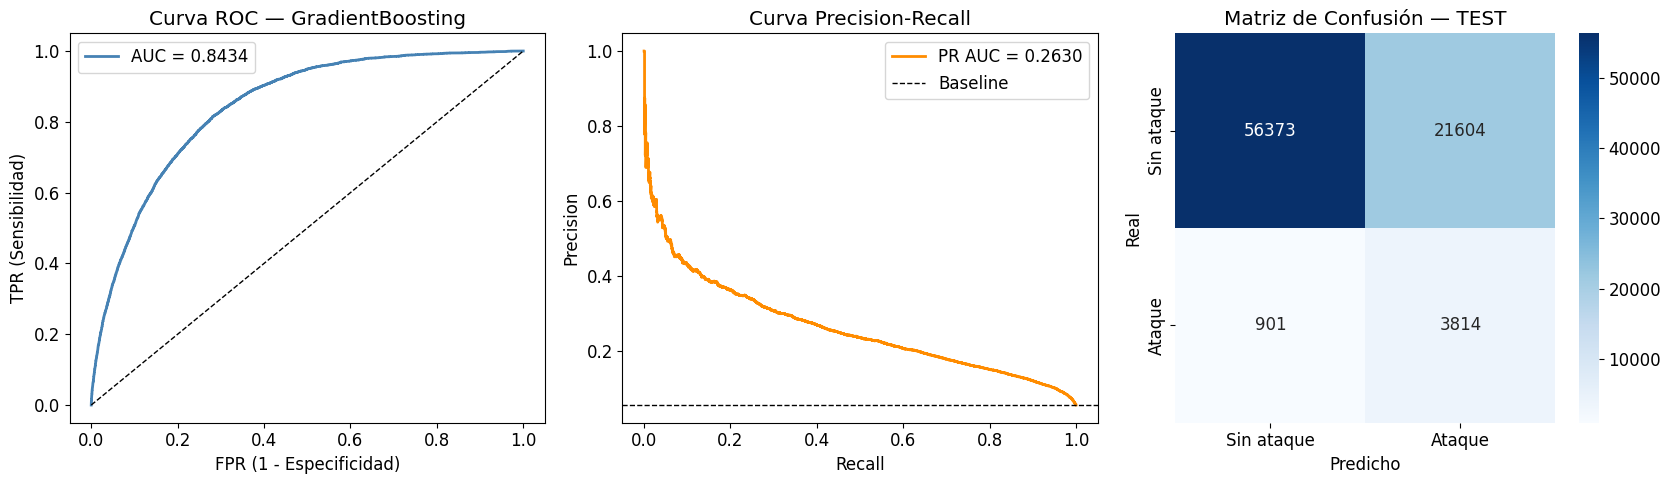

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, p_test_final)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {test_m["roc_auc"]:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('FPR (1 - Especificidad)')
axes[0].set_ylabel('TPR (Sensibilidad)')
axes[0].set_title(f'Curva ROC — {mejor_nombre}')
axes[0].legend()

# Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, p_test_final)
axes[1].plot(rec, prec, color='darkorange', lw=2, label=f'PR AUC = {test_m["pr_auc"]:.4f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', lw=1, label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()

# Matriz de confusión
plot_cm(y_test, y_pred_test, axes[2], title=f'Matriz de Confusión — TEST')

plt.tight_layout()
plt.show()

## 14. Validación cruzada robusta
**RepeatedStratifiedKFold** (5 folds × 3 repeticiones = 15 evaluaciones) sobre train+val.  
Se reporta solo ROC AUC para mantener el análisis claro.

In [ ]:
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

# LR: se pasa X_trainval_lr sin escalar — el Pipeline escala dentro de cada fold
# RF y GB: datos sin escalar directamente
cv_X = {
    'LogisticRegression': X_trainval_lr,
    'RandomForest'      : X_trainval,
    'GradientBoosting'  : X_trainval,
}

cv_rows = []
for nombre, (modelo, _, _) in model_map.items():
    print(f'CV robusta: {nombre}...')
    Xtv = cv_X[nombre]

    if nombre == 'GradientBoosting':
        sw_tv = compute_sample_weight('balanced', y_trainval)
        # params= en lugar de fit_params= (compatible con sklearn >= 1.4)
        # sklearn slicéa el array por fold correctamente
        res = cross_validate(modelo, Xtv, y_trainval, cv=rskf,
                             scoring='roc_auc', n_jobs=-1,
                             params={'sample_weight': sw_tv})
    else:
        res = cross_validate(modelo, Xtv, y_trainval, cv=rskf,
                             scoring='roc_auc', n_jobs=-1)

    aucs = res['test_score']
    cv_rows.append({
        'Modelo' : nombre,
        'Media'  : round(aucs.mean(), 4),
        'Mediana': round(float(np.median(aucs)), 4),
        'Std'    : round(aucs.std(), 4),
        'Min'    : round(aucs.min(), 4),
        'Max'    : round(aucs.max(), 4),
    })

print('\n=== CV Robusta — ROC AUC (5 folds × 3 repeticiones) ===')
pd.DataFrame(cv_rows)


CV robusta: LogisticRegression...
CV robusta: RandomForest...
CV robusta: GradientBoosting...

=== CV Robusta — ROC AUC (5 folds × 3 repeticiones) ===


,Modelo,Media,Mediana,Std,Min,Max
0,LogisticRegression,0.8447,0.8440,0.0028,0.8404,0.8512
1,RandomForest,0.8446,0.8447,0.0028,0.8406,0.8515
2,GradientBoosting,0.8458,0.8456,0.0028,0.8416,0.8524


## 15. Importancia de variables
Importancia interna del modelo final:  
- Logística → coeficientes y odds ratios  
- RF / GB → `feature_importances_`

            Feature  Importance
        AgeCategory    0.365647
      GeneralHealth    0.185116
          ChestScan    0.136941
          HadStroke    0.071596
                Sex    0.059778
       RemovedTeeth    0.052778
        HadDiabetes    0.038415
  DifficultyWalking    0.024988
       SmokerStatus    0.015785
            HadCOPD    0.011745
   HadKidneyDisease    0.006207
         SleepHours    0.004801
    LastCheckupTime    0.003511
 PhysicalHealthDays    0.003294
DeafOrHardOfHearing    0.003288
 


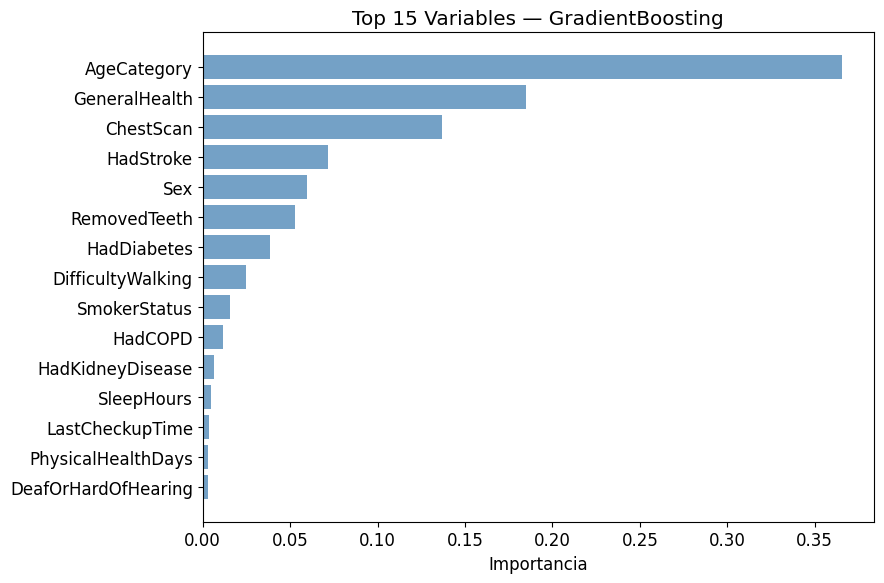

In [ ]:
TOP_N = 15

if mejor_nombre == 'LogisticRegression':
    coefs = modelo_final.named_steps['clf'].coef_[0]
    feat_imp_df = pd.DataFrame({
        'Feature'    : feature_names_lr,
        'Coeficiente': coefs,
        'Abs_Coef'   : np.abs(coefs),
        'Odds_Ratio' : np.exp(coefs),
    }).sort_values('Abs_Coef', ascending=False).reset_index(drop=True)

    print(feat_imp_df.head(TOP_N).to_string(index=False))

    top = feat_imp_df.head(TOP_N).sort_values('Coeficiente')
    fig, ax = plt.subplots(figsize=(9, 6))
    colores = ['crimson' if c > 0 else 'steelblue' for c in top['Coeficiente']]
    ax.barh(top['Feature'], top['Coeficiente'], color=colores, alpha=0.75)
    ax.axvline(0, color='black', lw=1)
    ax.set_title(f'Top {TOP_N} Coeficientes — Logística\n(rojo = aumenta riesgo)')
    ax.set_xlabel('Coeficiente')

else:
    fn = feature_names if mejor_nombre != 'LogisticRegression' else feature_names_lr
    feat_imp_df = pd.DataFrame({
        'Feature'   : fn,
        'Importance': modelo_final.feature_importances_,
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    print(feat_imp_df.head(TOP_N).to_string(index=False))
    print(" ")

    top = feat_imp_df.head(TOP_N).sort_values('Importance')
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top['Feature'], top['Importance'], color='steelblue', alpha=0.75)
    ax.set_title(f'Top {TOP_N} Variables — {mejor_nombre}')
    ax.set_xlabel('Importancia')

plt.tight_layout()
plt.show()

## 16. Análisis de residuos probabilísticos
Adaptación del análisis de residuos al caso de clasificación:  
- `residual = y − p̂` → sesgo; cercano a 0 = sin sesgo sistemático  
- `|residual|` → error absoluto por observación

In [ ]:
y_arr        = np.array(y_test)
residual     = y_arr - p_test_final
abs_residual = np.abs(residual)

print('Estadísticos de residuos probabilísticos en TEST:')
print(f'  Media residual     : {residual.mean():.5f}')
print(f'  Media |residual|   : {abs_residual.mean():.5f}')
print(f'  Media residual²    : {(residual**2).mean():.5f}')

Estadísticos de residuos probabilísticos en TEST:
  Media residual     : -0.28473
  Media |residual|   : 0.32228
  Media residual²    : 0.16626


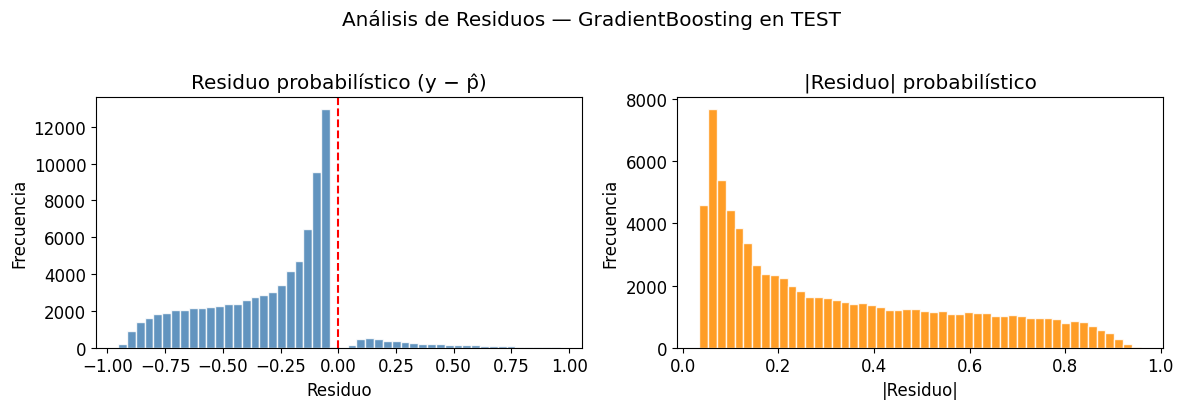

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma del residuo: negativo = modelo sobreestimó; positivo = subestimó
axes[0].hist(residual, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', lw=1.5, linestyle='--')
axes[0].set_title('Residuo probabilístico (y − p̂)')
axes[0].set_xlabel('Residuo')
axes[0].set_ylabel('Frecuencia')

# Histograma del |residuo|: mayoría cerca de 0 = buenas predicciones
axes[1].hist(abs_residual, bins=50, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('|Residuo| probabilístico')
axes[1].set_xlabel('|Residuo|')
axes[1].set_ylabel('Frecuencia')

plt.suptitle(f'Análisis de Residuos — {mejor_nombre} en TEST', y=1.02)
plt.tight_layout()
plt.show()

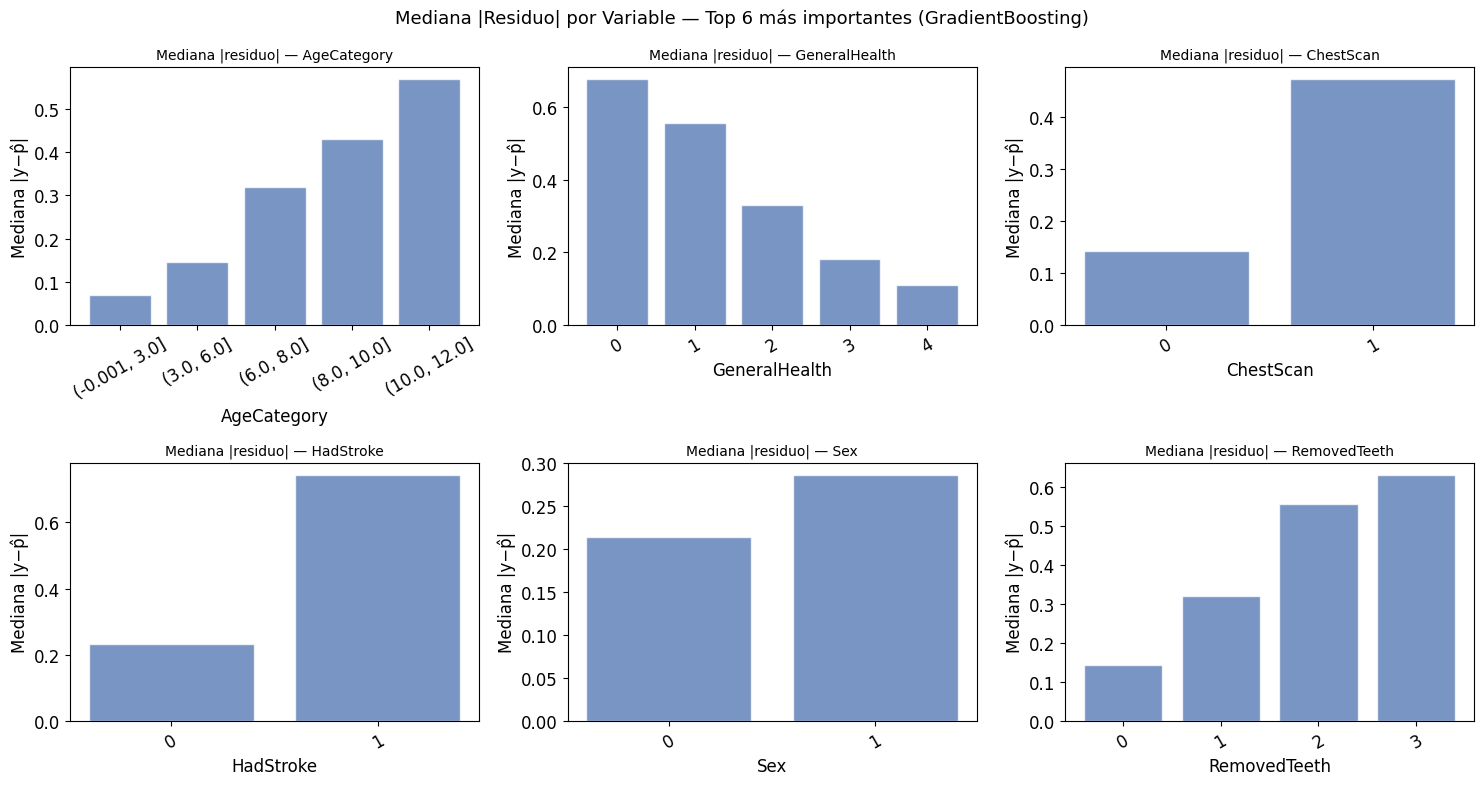

In [ ]:
# Residuo por variable — top 6 más importantes del modelo ganador
X_test_resid = X_test_lr if mejor_nombre == 'LogisticRegression' else X_test
df_resid = X_test_resid.copy().reset_index(drop=True)
df_resid['abs_residual'] = abs_residual

# Las 6 variables más importantes según feat_imp_df (calculado en la celda anterior)
vars_interes = feat_imp_df.head(6)['Feature'].tolist()

def resid_by_var(df, var, ax, n_bins=5):
    if df[var].nunique() > 10:
        df = df.copy()
        df['g'] = pd.qcut(df[var], q=n_bins, duplicates='drop')
        medians = df.groupby('g', observed=True)['abs_residual'].median()
        labels  = [str(g) for g in medians.index]
    else:
        medians = df.groupby(var)['abs_residual'].median().sort_index()
        labels  = [str(g) for g in medians.index]
    ax.bar(labels, medians.values, color='#4C72B0', alpha=0.75, edgecolor='white')
    ax.set_title(f'Mediana |residuo| — {var}', fontsize=10)
    ax.set_xlabel(var); ax.set_ylabel('Mediana |y−p̂|')
    ax.tick_params(axis='x', rotation=30)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, var in zip(axes.flatten(), vars_interes):
    resid_by_var(df_resid, var, ax)

plt.suptitle(f'Mediana |Residuo| por Variable — Top 6 más importantes ({mejor_nombre})', fontsize=13)
plt.tight_layout()
plt.show()

## 17. Intervalos de confianza bootstrap (no paramétricos)
Método percentil bootstrap con `BOOTSTRAP_N` remuestreos. No asume normalidad.

In [ ]:
def bootstrap_ci(y_true, y_prob, metric_fn, n_boot=BOOTSTRAP_N, seed=RANDOM_STATE):
    """Devuelve (estimación puntual, distribución bootstrap, [ic_inf, ic_sup])."""
    rng  = np.random.default_rng(seed)
    y, p = np.array(y_true), np.array(y_prob)
    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), size=len(y))
        if len(np.unique(y[idx])) < 2:
            continue
        boots.append(metric_fn(y[idx], p[idx]))
    boots = np.array(boots)
    punto = metric_fn(y, p)
    return punto, boots, np.percentile(boots, [2.5, 97.5])


print('Calculando bootstraps...')
auc_pt,  auc_dist,  auc_ci  = bootstrap_ci(y_test, p_test_final, roc_auc_score)
bri_pt,  bri_dist,  bri_ci  = bootstrap_ci(y_test, p_test_final, brier_score_loss)
mar_fn  = lambda y, p: float(np.mean(np.abs(y - p)))
mar_pt,  mar_dist,  mar_ci  = bootstrap_ci(y_test, p_test_final, mar_fn)

tabla_ci = pd.DataFrame([
    {'Métrica': 'ROC AUC',        'Estimación': round(auc_pt, 4), 'IC_inf_95': round(auc_ci[0], 4), 'IC_sup_95': round(auc_ci[1], 4)},
    {'Métrica': 'Brier Score',    'Estimación': round(bri_pt, 4), 'IC_inf_95': round(bri_ci[0], 4), 'IC_sup_95': round(bri_ci[1], 4)},
    {'Métrica': 'Media |y − p̂|', 'Estimación': round(mar_pt, 4), 'IC_inf_95': round(mar_ci[0], 4), 'IC_sup_95': round(mar_ci[1], 4)},
])

print(f'\n=== Intervalos de Confianza Bootstrap 95% — TEST ({BOOTSTRAP_N} remuestreos) ===')
tabla_ci

Calculando bootstraps...

=== Intervalos de Confianza Bootstrap 95% — TEST (1000 remuestreos) ===


,Métrica,Estimación,IC_inf_95,IC_sup_95
0,ROC AUC,0.8434,0.8386,0.8488
1,Brier Score,0.1663,0.1648,0.1677
2,Media |y − p̂|,0.3223,0.3206,0.3240


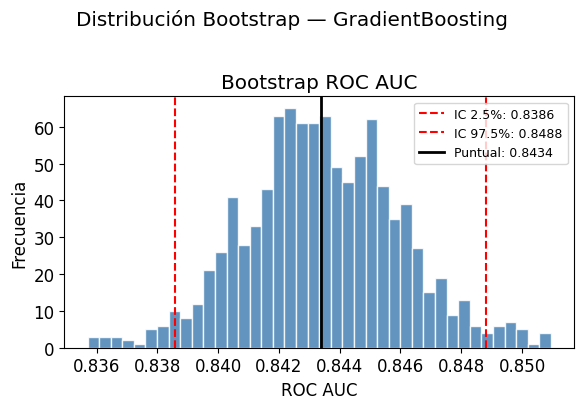

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(auc_dist, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(auc_ci[0], color='red', lw=1.5, linestyle='--', label=f'IC 2.5%: {auc_ci[0]:.4f}')
ax.axvline(auc_ci[1], color='red', lw=1.5, linestyle='--', label=f'IC 97.5%: {auc_ci[1]:.4f}')
ax.axvline(auc_pt, color='black', lw=2, label=f'Puntual: {auc_pt:.4f}')

ax.set_title('Bootstrap ROC AUC')
ax.set_xlabel('ROC AUC')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)

plt.suptitle(f'Distribución Bootstrap — {mejor_nombre}', y=1.02)
plt.tight_layout()
plt.show()

## 18. Conclusión final

In [ ]:
top3_vars = feat_imp_df.head(3)['Feature'].tolist()
tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_test, y_pred_test).ravel()

print('=' * 60)
print('                 CONCLUSIÓN FINAL')
print('=' * 60)
print(f'  Mejor modelo          : {mejor_nombre}')
print(f'  Hiperparámetros       : {mejores_params}')
print(f'  Umbral                : {mejor_umbral:.4f}')
print(f'  ROC AUC — TEST        : {test_m["roc_auc"]:.4f}')
print(f'  PR  AUC — TEST        : {test_m["pr_auc"]:.4f}')
print(f'  Cumple AUC >= {SUCCESS_AUC}?     {"SÍ ✓" if test_m["roc_auc"] >= SUCCESS_AUC else "NO ✗"}')
print(f'  Top 3 variables       : {top3_vars}')
print()
print(f'  Falsos Negativos (FN) : {fn_f:,}')
print(f'    → Personas con ataque clasificadas como sanas.')
print(f'    → Son el error más costoso clínicamente: retrasan diagnóstico.')
print()
print(f'  Falsos Positivos (FP) : {fp_f:,}')
print(f'    → Personas sanas clasificadas como en riesgo.')
print(f'    → Generan consultas innecesarias, pero de menor impacto clínico.')
print('=' * 60)

                 CONCLUSIÓN FINAL
  Mejor modelo          : GradientBoosting
  Hiperparámetros       : {'learning_rate': np.float64(0.06144386194113441), 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 121, 'subsample': np.float64(0.5035331526098588)}
  Umbral                : 0.4806
  ROC AUC — TEST        : 0.8434
  PR  AUC — TEST        : 0.2630
  Cumple AUC >= 0.85?     NO ✗
  Top 3 variables       : ['AgeCategory', 'GeneralHealth', 'ChestScan']

  Falsos Negativos (FN) : 901
    → Personas con ataque clasificadas como sanas.
    → Son el error más costoso clínicamente: retrasan diagnóstico.

  Falsos Positivos (FP) : 21,604
    → Personas sanas clasificadas como en riesgo.
    → Generan consultas innecesarias, pero de menor impacto clínico.


## 19. Exportación modelo final
Exportamos el mejor modelo en validación, entrenado con la totalidad de los datos, en formato .pkl para su posterior despliegue.


In [ ]:
# Combinar conjuntos para el modelo de producción
if mejor_nombre == 'LogisticRegression':
    X_prod = pd.concat([X_trainval_lr, X_test_lr], ignore_index=True)
else:
    X_prod = pd.concat([X_trainval, X_test], ignore_index=True)

y_prod = pd.concat([y_trainval, y_test], ignore_index=True)

print(f'Modelo para producción entrenado con: {len(y_prod):,} observaciones')

# Reentrenar con todos los datos
if mejor_nombre == 'LogisticRegression':
    modelo_produccion = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced', max_iter=2000,
            random_state=RANDOM_STATE, **mejores_params
        ))
    ])
    modelo_produccion.fit(X_prod, y_prod)
    columnas_prod = list(X_trainval_lr.columns)

elif mejor_nombre == 'RandomForest':
    modelo_produccion = RandomForestClassifier(
        random_state=RANDOM_STATE, n_jobs=-1, **mejores_params
    )
    modelo_produccion.fit(X_prod, y_prod)
    columnas_prod = list(X_trainval.columns)

else:  # GradientBoosting
    sw_prod = compute_sample_weight('balanced', y_prod)
    modelo_produccion = GradientBoostingClassifier(
        random_state=RANDOM_STATE, **mejores_params
    )
    modelo_produccion.fit(X_prod, y_prod, sample_weight=sw_prod)
    columnas_prod = list(X_trainval.columns)

print(f'{mejor_nombre} entrenado con todos los datos. ✓')

# Exportar paquete completo para despliegue en Streamlit
paquete_modelo = {
    'modelo':             modelo_produccion,
    'nombre_modelo':      mejor_nombre,
    'umbral':             mejor_umbral,
    'columnas_esperadas': columnas_prod,
}

nombre_archivo = f'{mejor_nombre}_produccion.pkl'

with open(nombre_archivo, 'wb') as f:
    pickle.dump(paquete_modelo, f)

print(f'Paquete guardado como {nombre_archivo}')

try:
    files.download(nombre_archivo)
    print('Descarga finalizada. ✓')
except ImportError:
    print(f'No estás en Colab. Archivo guardado localmente: {nombre_archivo}')

Modelo para producción entrenado con: 413,460 observaciones
GradientBoosting entrenado con todos los datos. ✓
Paquete guardado como GradientBoosting_produccion.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga finalizada. ✓
